# Predicting Age from MRI-Derived Brain Measurements and Clinical Characteristics Using Machine Learning


## 1. Import Libraries

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier
)

from sklearn.tree import (
    DecisionTreeRegressor,
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import (
    LinearRegression,
    RidgeCV,
    LassoCV,
    ElasticNetCV,
    LogisticRegression
)

## 2. Load Final Modeling Dataset



In [2]:
df = pd.read_excel("OASIS-1.xlsx")

print("Dataset shape:", df.shape)
df.head()
df.shape

Dataset shape: (436, 12)


(436, 12)

## 3. Basic Cleaning and Target Definition

In [3]:
df = df.drop(columns=["ID", "Hand", "Delay"])

df["M/F"] = df["M/F"].map({"M": 1, "F": 0})

# Drop rows missing ANY value needed for modeling (not just Age)
df = df.dropna().copy()

# Define BOTH from the same cleaned df — this keeps them aligned
y = df["Age"]
X = df.drop(columns=["Age"])

print("Cleaned dataset shape:", df.shape)
print("X shape:", X.shape, "| y shape:", y.shape)   # must match

Cleaned dataset shape: (216, 9)
X shape: (216, 8) | y shape: (216,)


## 4. Feature Set


In [4]:
features = [
    "M/F",
    "Educ",
    "SES",
    "MMSE",
    "CDR",
    "eTIV",
    "nWBV",
    "ASF"
]

df_model = df[["Age"] + features].dropna()

print(df_model.shape)

(216, 9)


## 5. Dataset Overview and Missing Values

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 216 entries, 0 to 415
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   M/F     216 non-null    int64  
 1   Age     216 non-null    int64  
 2   Educ    216 non-null    float64
 3   SES     216 non-null    float64
 4   MMSE    216 non-null    float64
 5   CDR     216 non-null    float64
 6   eTIV    216 non-null    int64  
 7   nWBV    216 non-null    float64
 8   ASF     216 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 16.9 KB
None


In [6]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

## 6. Summary Statistics

In [7]:
summary_stats = df_model.describe()
summary_stats

,Age,M/F,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF
count,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000
mean,72.444444,0.328704,3.231481,2.490741,27.324074,0.261574,1458.638889,0.750500,1.217176
std,12.306424,0.470833,1.333689,1.120593,3.436680,0.382593,160.523125,0.048271,0.128858
min,33.000000,0.000000,1.000000,1.000000,15.000000,0.000000,1123.000000,0.644000,0.881000
25%,66.000000,0.000000,2.000000,2.000000,26.000000,0.000000,1346.000000,0.715000,1.141750
50%,73.000000,0.000000,3.000000,2.000000,29.000000,0.000000,1445.500000,0.748500,1.214500
75%,81.000000,1.000000,4.000000,3.000000,30.000000,0.500000,1536.500000,0.786000,1.304000
max,96.000000,1.000000,5.000000,5.000000,30.000000,2.000000,1992.000000,0.841000,1.563000


## 7. Distribution of Age and Boxplot of Age

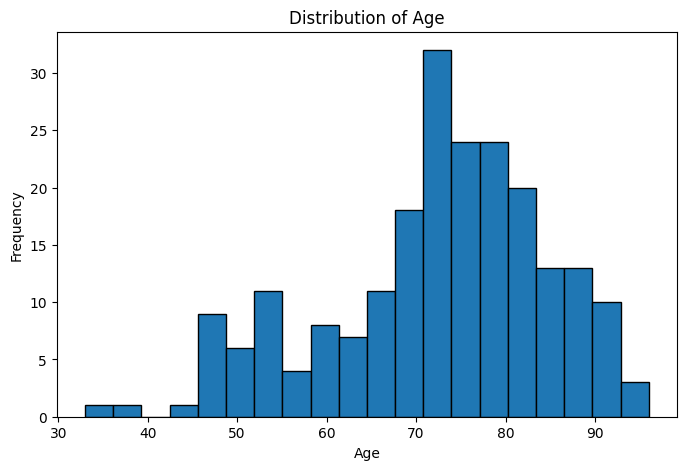

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df_model["Age"], bins=20, edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

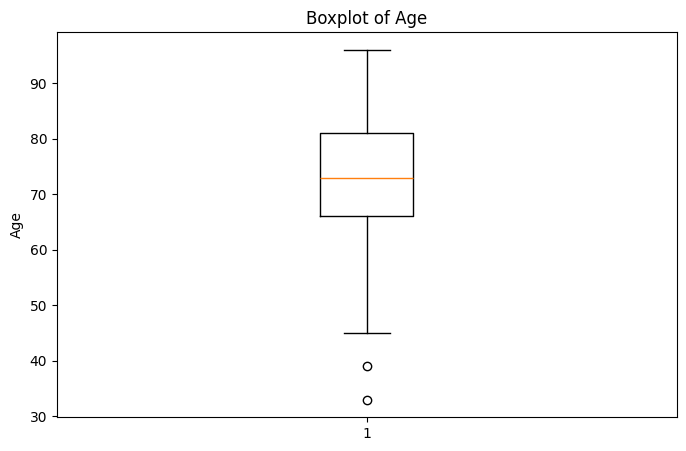

In [9]:
plt.figure(figsize=(8,5))
plt.boxplot(df_model["Age"])
plt.title("Boxplot of Age")
plt.ylabel("Age")
plt.show()

## 8. Correlation Analysis

In [10]:
corr = df[["Age"] + features].corr(numeric_only=True)

corr_target = corr["Age"].sort_values(ascending=False)
corr_target

Age     1.000000
CDR     0.310571
SES     0.157806
eTIV    0.038419
M/F    -0.022922
ASF    -0.034442
Educ   -0.206650
MMSE   -0.310579
nWBV   -0.735933
Name: Age, dtype: float64

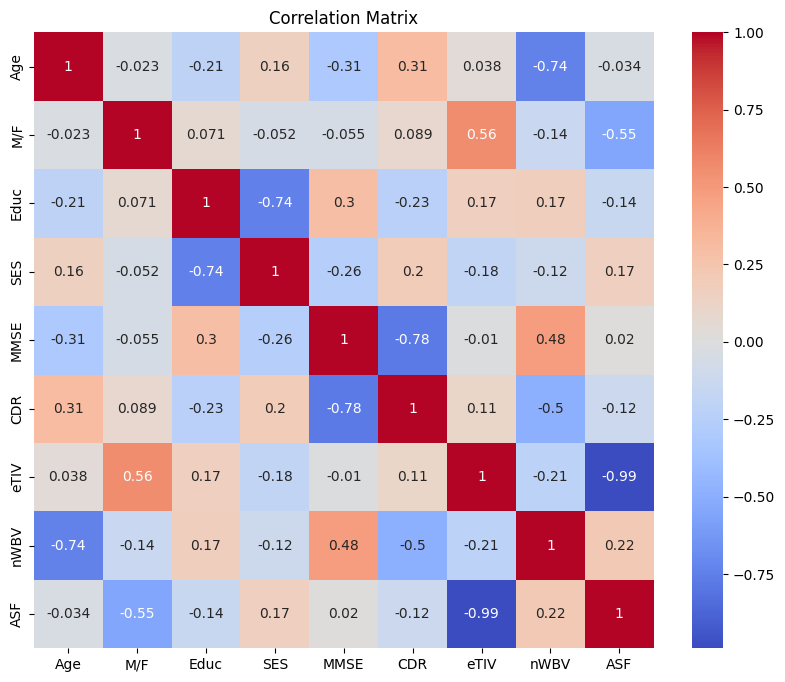

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df_model.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

## 9. Scatterplots of Selected MRI Features vs Age

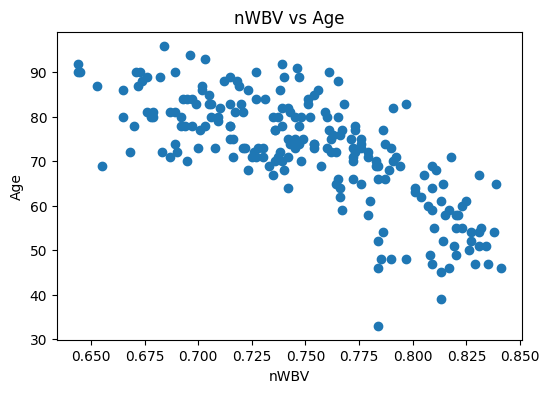

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(df["nWBV"], df["Age"])
plt.xlabel("nWBV")
plt.ylabel("Age")
plt.title("nWBV vs Age")
plt.show()

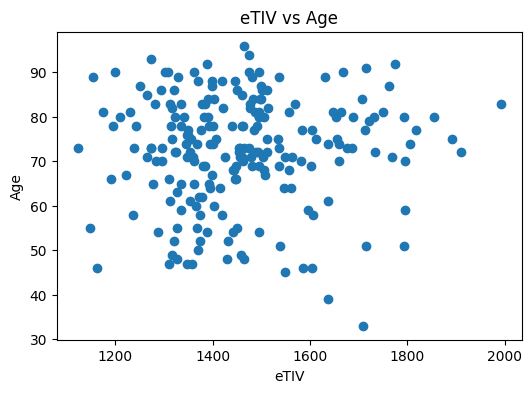

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(df["eTIV"], df["Age"])
plt.xlabel("eTIV")
plt.ylabel("Age")
plt.title("eTIV vs Age")
plt.show()

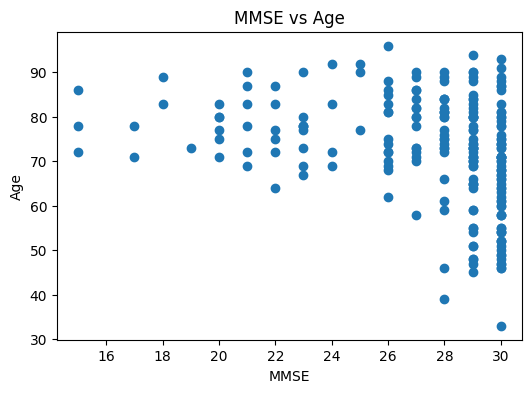

In [14]:
plt.figure(figsize=(6,4))
plt.scatter(df_model["MMSE"], df_model["Age"])
plt.xlabel("MMSE")
plt.ylabel("Age")
plt.title("MMSE vs Age")
plt.show()

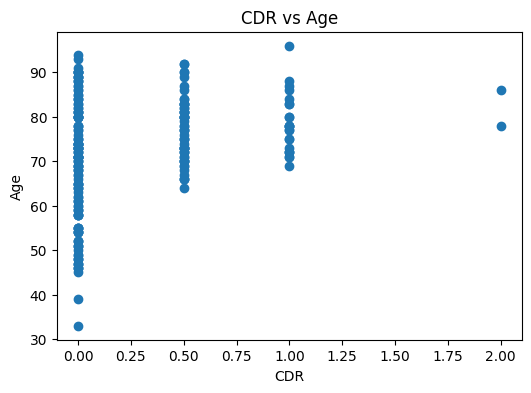

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(df_model["CDR"], df_model["Age"])
plt.xlabel("CDR")
plt.ylabel("Age")
plt.title("CDR vs Age")
plt.show()

## 10. Multicollinearity Check Using VIF

VIF is calculated using the final predictor set. Very high VIF values suggest redundant predictors.

In [16]:
X_vif = sm.add_constant(X.copy())

vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

vif_data = vif_data[
    vif_data["Feature"] != "const"
].sort_values(
    "VIF",
    ascending=False
)

display(vif_data)

,Feature,VIF
6,eTIV,50.591045
8,ASF,49.303214
4,MMSE,2.731941
5,CDR,2.697161
2,Educ,2.334869
3,SES,2.266732
1,M/F,1.481540
7,nWBV,1.443623


## 11. Train/Test Split

The same split is used for all regression models for fair comparison.

In [17]:

X_train , X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 162
Testing rows: 54


## 12. LASSO Feature Selection

In [18]:
lasso_fs = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, max_iter=100000, random_state=42))
])

lasso_fs.fit(X_train, y_train)

coef = pd.Series(
    lasso_fs.named_steps["lasso"].coef_,
    index=X_train.columns
)

selected = coef[coef != 0].sort_values(key=abs, ascending=False)
selected

nWBV   -9.148162
M/F    -1.520488
SES     0.577219
MMSE    0.419022
ASF     0.309372
Educ   -0.128060
CDR    -0.101622
dtype: float64

## 13. Linear Regression

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression
MAE: 5.25654129856722
RMSE: 7.075114268730545
R2: 0.6542182675112436


## 14. Ridge Regression

In [20]:
alphas = [0.01, 0.1, 1, 10, 100]

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas))
])

ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge = r2_score(y_test, pred_ridge)

print("Ridge Regression")
print("Best Alpha:", ridge.named_steps["ridge"].alpha_)
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R2:", r2_ridge)

Ridge Regression
Best Alpha: 10.0
MAE: 5.226251471870125
RMSE: 7.148701254839806
R2: 0.6469880351264876


## 15. LASSO Regression Model

This uses LASSO as a prediction model, not only as feature selection.

In [21]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, max_iter=100000, random_state=42))
])

lasso_model.fit(X_train, y_train)
pred_lasso = lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
r2_lasso = r2_score(y_test, pred_lasso)

print("LASSO Regression")
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)
print("R2:", r2_lasso)

LASSO Regression
MAE: 5.282402414838348
RMSE: 7.179088274074937
R2: 0.6439805573764471


## Elastic Net Regression

In [22]:
elastic_net = make_pipeline(
    StandardScaler(),
    ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        cv=10,
        max_iter=10000,
        random_state=42
    )
)

elastic_net.fit(X_train, y_train)

# Numeric regression predictions
pred_elastic = elastic_net.predict(X_test)

elastic_model = elastic_net.named_steps["elasticnetcv"]

mae_elastic = mean_absolute_error(y_test, pred_elastic)
rmse_elastic = np.sqrt(mean_squared_error(y_test, pred_elastic))
r2_elastic = r2_score(y_test, pred_elastic)

print("Elastic Net Regression")
print(f"Best alpha    : {elastic_model.alpha_:.4f}")
print(f"Best l1_ratio : {elastic_model.l1_ratio_}")
print(f"Train R²      : {elastic_net.score(X_train, y_train):.4f}")
print(f"Test R²       : {r2_elastic:.4f}")
print(f"Test RMSE     : {rmse_elastic:.3f}")
print(f"Test MAE      : {mae_elastic:.3f}")

Elastic Net Regression
Best alpha    : 0.4720
Best l1_ratio : 1.0
Train R²      : 0.5355
Test R²       : 0.6344
Test RMSE     : 7.275
Test MAE      : 5.461


## 16. Decision Tree Regression

In [23]:
tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

mae_tree = mean_absolute_error(y_test, pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, pred_tree))
r2_tree = r2_score(y_test, pred_tree)

print("Decision Tree")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R2:", r2_tree)

Decision Tree
MAE: 6.851260622093954
RMSE: 8.900388524959753
R2: 0.45279121716578075


In [24]:
tree_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
}).sort_values("Importance", ascending=False)

tree_importance.head(10)

,Feature,Importance
6,nWBV,0.825478
0,M/F,0.062997
5,eTIV,0.058987
2,SES,0.036225
3,MMSE,0.016314
1,Educ,0.000000
4,CDR,0.000000
7,ASF,0.000000


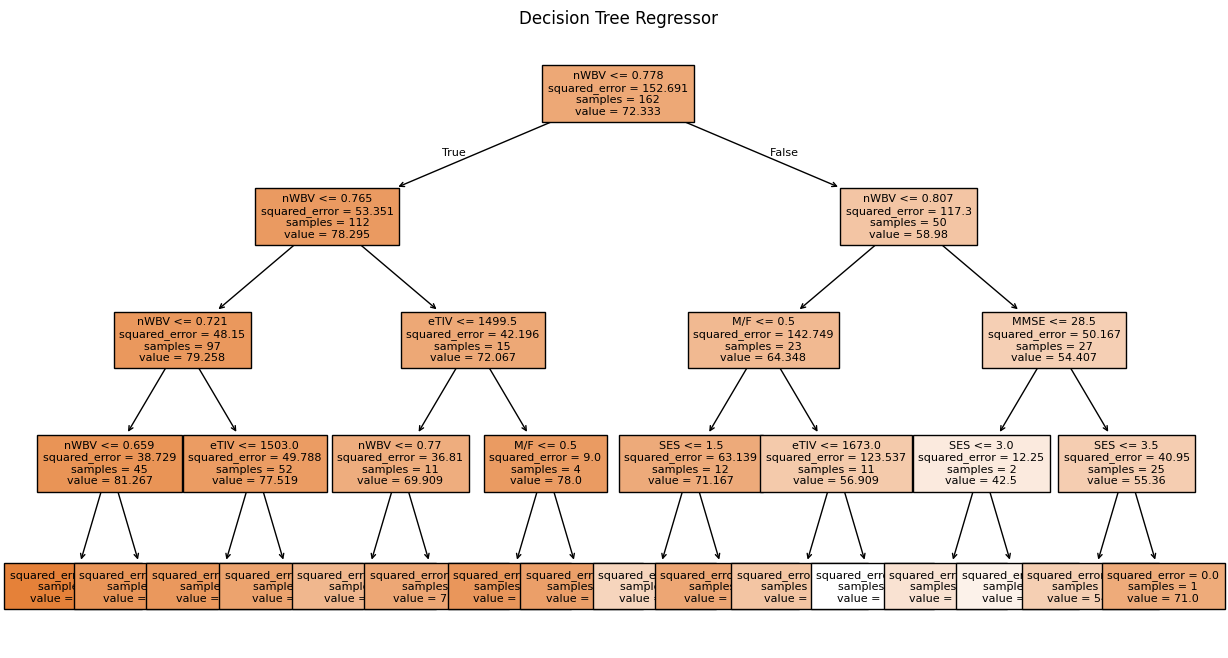

In [25]:
plt.figure(figsize=(15,8))
plot_tree(
    tree,
    feature_names=X.columns,
    filled=True,
    fontsize=8
)
plt.title("Decision Tree Regressor")
plt.show()

## 17. Random Forest Regression

In [26]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest
MAE: 6.138222222222221
RMSE: 7.446349819181854
R2: 0.6169795176530786


In [27]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance.head(10)

,Feature,Importance
6,nWBV,0.695018
5,eTIV,0.066159
7,ASF,0.064985
3,MMSE,0.060075
2,SES,0.044396
1,Educ,0.034019
4,CDR,0.021006
0,M/F,0.014342


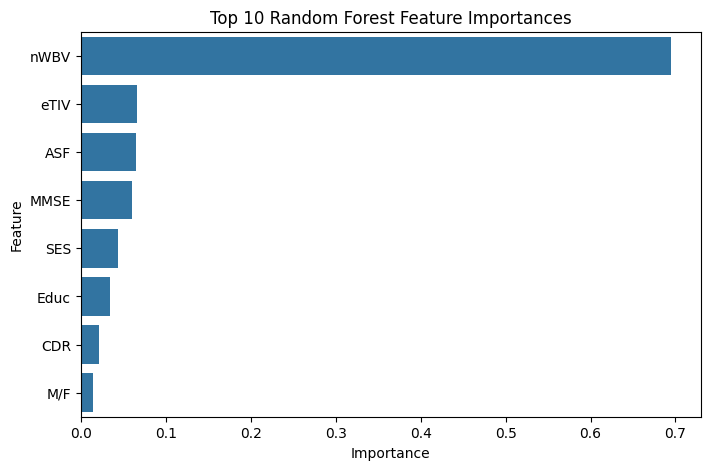

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=rf_importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 18. Tuned Random Forest Regression

In [29]:
rf_tuned = RandomForestRegressor(
    n_estimators=1000,
    max_depth=3,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)
pred_rf_tuned = rf_tuned.predict(X_test)

mae_rf_tuned = mean_absolute_error(y_test, pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, pred_rf_tuned)

print("Tuned Random Forest")
print("MAE:", mae_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("R2:", r2_rf_tuned)

Tuned Random Forest
MAE: 5.782662431460589
RMSE: 6.983634974930623
R2: 0.6631021870621684


## Gradient Boosting

In [30]:
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid={
        "n_estimators":  [300, 500, 700, 1000],
        "learning_rate": [0.1, 0.05, 0.025],
        "max_depth":     [3, 5, 7],
    },
    cv=10, scoring="r2", n_jobs=-1
).fit(X_train, y_train)

pred_gb = gb_grid.predict(X_test)
print("Best params:", gb_grid.best_params_)
print(f"CV R²: {gb_grid.best_score_:.4f} | Test R²: {r2_score(y_test, pred_gb):.4f}")

Best params: {'learning_rate': 0.025, 'max_depth': 3, 'n_estimators': 300}
CV R²: 0.4157 | Test R²: 0.5971


## SUPPORT VECTOR REGRESSION

In [31]:
svr_grid = GridSearchCV(
    make_pipeline(
        StandardScaler(),
        SVR()
    ),
    param_grid={
        "svr__kernel": ["linear", "rbf", "poly"],
        "svr__C": [0.1, 1, 10, 100],
        "svr__gamma": ["scale", 0.01, 0.1]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)

svr_grid.fit(X_train, y_train)

pred_svr = svr_grid.predict(X_test)

mae_svr = mean_absolute_error(y_test, pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, pred_svr))
r2_svr = r2_score(y_test, pred_svr)

print("Support Vector Regression")
print("Best params:", svr_grid.best_params_)
print(f"CV R²   : {svr_grid.best_score_:.4f}")
print(f"Test R² : {r2_svr:.4f}")
print(f"RMSE    : {rmse_svr:.3f}")
print(f"MAE     : {mae_svr:.3f}")

Support Vector Regression
Best params: {'svr__C': 100, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}
CV R²   : 0.5378
Test R² : 0.6394
RMSE    : 7.225
MAE     : 5.778


## Grid Search Random Forest

In [32]:

rf_grid = GridSearchCV(
    RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1),
    {
        "max_depth":[None, 5, 10, 20],
        "max_features":[2, 3, 4, 8],
        "min_samples_leaf":[1, 2, 4],
    },
    cv=10, scoring="r2", n_jobs=-1
).fit(X_train, y_train)

print("Best:", rf_grid.best_params_)
print(f"CV R²: {rf_grid.best_score_:.4f} | Test R²: {r2_score(y_test, rf_grid.predict(X_test)):.4f}")

Best: {'max_depth': 10, 'max_features': 4, 'min_samples_leaf': 4}
CV R²: 0.5503 | Test R²: 0.6469


## 19. Model Comparison

In [33]:
# ============================================================
# FINAL REGRESSION MODEL COMPARISON
# ============================================================

# Gradient Boosting metrics
mae_gb = mean_absolute_error(y_test, pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))
r2_gb = r2_score(y_test, pred_gb)

# Grid-searched Random Forest predictions and metrics
pred_rf_grid_reg = rf_grid.predict(X_test)

mae_rf_grid = mean_absolute_error(y_test, pred_rf_grid_reg)
rmse_rf_grid = np.sqrt(mean_squared_error(y_test, pred_rf_grid_reg))
r2_rf_grid = r2_score(y_test, pred_rf_grid_reg)

regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "LASSO Regression",
        "Elastic Net",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest",
        "Gradient Boosting",
        "Support Vector Regression",
        "Grid-Searched Random Forest"
    ],

    "MAE": [
        mae_lr,
        mae_ridge,
        mae_lasso,
        mae_elastic,
        mae_tree,
        mae_rf,
        mae_rf_tuned,
        mae_gb,
        mae_svr,
        mae_rf_grid
    ],

    "RMSE": [
        rmse_lr,
        rmse_ridge,
        rmse_lasso,
        rmse_elastic,
        rmse_tree,
        rmse_rf,
        rmse_rf_tuned,
        rmse_gb,
        rmse_svr,
        rmse_rf_grid
    ],

    "R2": [
        r2_lr,
        r2_ridge,
        r2_lasso,
        r2_elastic,
        r2_tree,
        r2_rf,
        r2_rf_tuned,
        r2_gb,
        r2_svr,
        r2_rf_grid
    ]
})

regression_results = regression_results.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)

print("Final Regression Model Comparison")
display(regression_results)

Final Regression Model Comparison


,Model,MAE,RMSE,R2
0,Tuned Random Forest,5.782662,6.983635,0.663102
1,Linear Regression,5.256541,7.075114,0.654218
2,Ridge Regression,5.226251,7.148701,0.646988
3,Grid-Searched Random Forest,5.915187,7.149696,0.646890
4,LASSO Regression,5.282402,7.179088,0.643981
5,Support Vector Regression,5.777964,7.225201,0.639392
6,Elastic Net,5.460954,7.274657,0.634439
7,Random Forest,6.138222,7.446350,0.616980
8,Gradient Boosting,6.323293,7.636821,0.597134
9,Decision Tree,6.851261,8.900389,0.452791


## 20. PCA Dimension Reduction

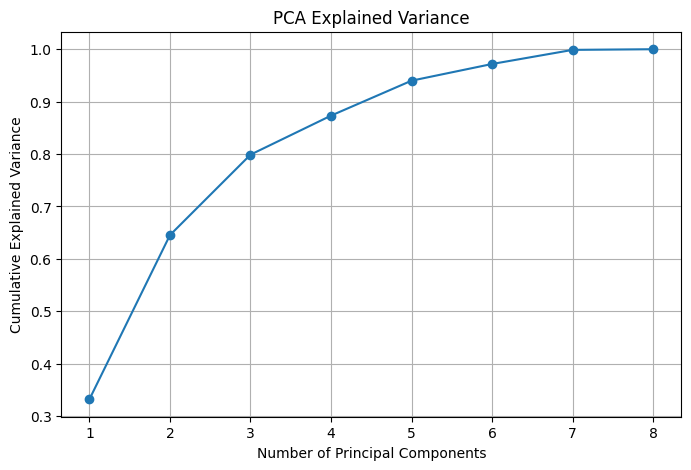

In [34]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = explained.cumsum()

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cum_explained) + 1),
    cum_explained,
    marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

In [35]:
pca_table = pd.DataFrame({
    "PC": range(1, len(explained) + 1),
    "Variance Explained": explained,
    "Cumulative Variance": cum_explained
})

pca_table.head(10)

,PC,Variance Explained,Cumulative Variance
0,1,0.332328,0.332328
1,2,0.313134,0.645462
2,3,0.153391,0.798853
3,4,0.074463,0.873315
4,5,0.066665,0.939980
5,6,0.031852,0.971832
6,7,0.026907,0.998739
7,8,0.001261,1.000000


## 21. Clustering 

In [36]:
# ============================================================
# K-MEANS CLUSTERING
# ============================================================

# Scale predictors
Xs = StandardScaler().fit_transform(X)

# Compare different values of k
k_results = []

for k in range(2, 10):

    km_test = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42,
        algorithm="lloyd"
    )

    cluster_labels = km_test.fit_predict(Xs)

    silhouette = silhouette_score(
        Xs,
        cluster_labels
    )

    k_results.append({
        "k": k,
        "Inertia": km_test.inertia_,
        "Silhouette": silhouette
    })

    print(
        f"k={k}  "
        f"inertia={km_test.inertia_:8.1f}  "
        f"silhouette={silhouette:.4f}"
    )

k_results = pd.DataFrame(k_results)

display(k_results)

k=2  inertia=  1316.3  silhouette=0.2451
k=3  inertia=   996.8  silhouette=0.2813
k=4  inertia=   868.4  silhouette=0.2142
k=5  inertia=   782.3  silhouette=0.2135
k=6  inertia=   725.5  silhouette=0.2210
k=7  inertia=   678.1  silhouette=0.1946
k=8  inertia=   640.6  silhouette=0.2035
k=9  inertia=   616.1  silhouette=0.1913


,k,Inertia,Silhouette
0,2,1316.293483,0.245118
1,3,996.837713,0.281279
2,4,868.447297,0.214206
3,5,782.343824,0.213502
4,6,725.494272,0.220953
5,7,678.113498,0.194603
6,8,640.619618,0.203487
7,9,616.072789,0.191273


In [37]:
# Final K-Means model
best_k = 3

km_final = KMeans(
    n_clusters=best_k,
    n_init=20,
    random_state=42,
    algorithm="lloyd"
)

cluster_labels = km_final.fit_predict(Xs)

X_clustered = X.copy()
X_clustered["cluster"] = cluster_labels

print("\nCluster means:")
display(
    X_clustered.groupby("cluster").mean().round(2)
)

print("\nCluster sizes:")
print(
    X_clustered["cluster"].value_counts().sort_index()
)


Cluster means:


,M/F,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF
cluster,,,,,,,,
0,0.83,4.03,1.93,28.22,0.21,1645.36,0.74,1.07
1,0.36,2.19,3.24,21.88,0.82,1445.05,0.70,1.22
2,0.06,3.20,2.50,28.85,0.08,1367.81,0.77,1.29



Cluster sizes:
cluster
0     59
1     42
2    115
Name: count, dtype: int64


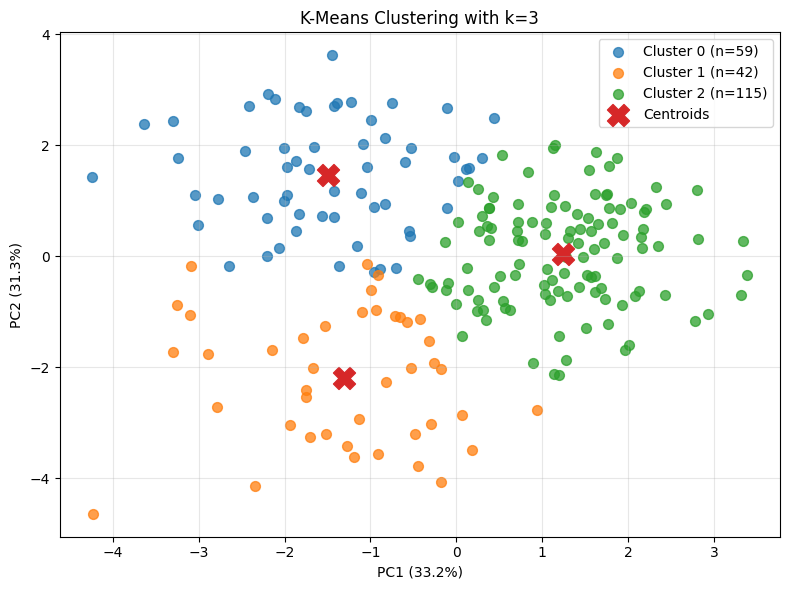

In [38]:
# PCA for visualization
pca_cluster = PCA(n_components=2)

pcs = pca_cluster.fit_transform(Xs)

centroids_pca = pca_cluster.transform(
    km_final.cluster_centers_
)

variance = (
    pca_cluster.explained_variance_ratio_ * 100
)

plt.figure(figsize=(8, 6))

for cluster_number in range(best_k):

    mask = cluster_labels == cluster_number

    plt.scatter(
        pcs[mask, 0],
        pcs[mask, 1],
        s=50,
        alpha=0.75,
        label=(
            f"Cluster {cluster_number} "
            f"(n={mask.sum()})"
        )
    )

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel(
    f"PC1 ({variance[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({variance[1]:.1f}%)"
)

plt.title(
    f"K-Means Clustering with k={best_k}"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 22. Generalized Linear Model (Gaussian GLM)

In [39]:
X_glm = sm.add_constant(X)

glm = sm.GLM(
    y,
    X_glm,
    family=sm.families.Gaussian()
)

glm_results = glm.fit()
print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    Age   No. Observations:                  216
Model:                            GLM   Df Residuals:                      207
Model Family:                Gaussian   Df Model:                            8
Link Function:               Identity   Scale:                          66.709
Method:                          IRLS   Log-Likelihood:                -755.53
Date:                Thu, 23 Jul 2026   Deviance:                       13809.
Time:                        19:47:33   Pearson chi2:                 1.38e+04
No. Iterations:                     3   Pseudo R-squ. (CS):             0.7281
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        130.4978     73.787      1.769      0.0

## Random forest Regression

In [40]:

rf_grid = GridSearchCV(
    RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1),
    {
        "max_depth":[None, 5, 10, 20],
        "max_features":[2, 3, 4, 8],
        "min_samples_leaf":[1, 2, 4],
    },
    cv=10, scoring="r2", n_jobs=-1
).fit(X_train, y_train)

print("Best:", rf_grid.best_params_)
print(f"CV R²: {rf_grid.best_score_:.4f} | Test R²: {r2_score(y_test, rf_grid.predict(X_test)):.4f}")

Best: {'max_depth': 10, 'max_features': 4, 'min_samples_leaf': 4}
CV R²: 0.5503 | Test R²: 0.6469


## Classification Target

In [41]:
# ============================================================
# CLASSIFICATION TARGET AND TRAIN/TEST SPLIT
# ============================================================

y_class = pd.cut(
    y,
    bins=[0, 65, 75, np.inf],
    labels=["young", "mid", "old"],
    include_lowest=True
)

print("Class distribution:")
print(y_class.value_counts())

print("\nClass proportions:")
print(y_class.value_counts(normalize=True).round(4))

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y_class,
    test_size=0.25,
    random_state=42,
    stratify=y_class
)

print("\nTraining class distribution:")
print(ytr.value_counts())

print("\nTesting class distribution:")
print(yte.value_counts())

Class distribution:
Age
old      92
mid      72
young    52
Name: count, dtype: int64

Class proportions:
Age
old      0.4259
mid      0.3333
young    0.2407
Name: proportion, dtype: float64

Training class distribution:
Age
old      69
mid      54
young    39
Name: count, dtype: int64

Testing class distribution:
Age
old      23
mid      18
young    13
Name: count, dtype: int64


## Linear Discriminant Analysis 

In [42]:
from sklearn.metrics import classification_report, accuracy_score
lda = LinearDiscriminantAnalysis()

lda.fit(Xtr, ytr)

pred_lda = lda.predict(Xte)

print(
    "LDA Test Accuracy:",
    round(accuracy_score(yte, pred_lda), 4)
)

print(
    classification_report(
        yte,
        pred_lda,
        zero_division=0
    )
)

LDA Test Accuracy: 0.6667
              precision    recall  f1-score   support

         mid       0.50      0.33      0.40        18
         old       0.69      0.87      0.77        23
       young       0.77      0.77      0.77        13

    accuracy                           0.67        54
   macro avg       0.65      0.66      0.65        54
weighted avg       0.65      0.67      0.65        54



## Logistic Regression Classification 

In [43]:


# Split the classification data
Xtr, Xte, ytr, yte = train_test_split(
    X,
    y_class,
    test_size=0.25,
    random_state=42,
    stratify=y_class
)

# Create and train Logistic Regression model
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        random_state=42
    )
)

clf.fit(Xtr, ytr)

# Predictions
pred_logistic = clf.predict(Xte)

# Cross-validation accuracy
cv_accuracy = cross_val_score(
    clf,
    Xtr,
    ytr,
    cv=10,
    scoring="accuracy"
).mean()

# Test accuracy
test_accuracy = accuracy_score(
    yte,
    pred_logistic
)

# Majority-class baseline
baseline_accuracy = y_class.value_counts(
    normalize=True
).max()

print("Logistic Regression Classification")
print(f"CV accuracy   : {cv_accuracy:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Baseline      : {baseline_accuracy:.4f}")

# Class labels
labels = list(clf.classes_)

# Confusion matrix
confusion = confusion_matrix(
    yte,
    pred_logistic,
    labels=labels
)

confusion_df = pd.DataFrame(
    confusion,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

print("\nConfusion Matrix:")
print(confusion_df)

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        yte,
        pred_logistic,
        zero_division=0
    )
)

Logistic Regression Classification
CV accuracy   : 0.6184
Test accuracy : 0.6667
Baseline      : 0.4259

Confusion Matrix:
              Predicted mid  Predicted old  Predicted young
Actual mid                5              9                4
Actual old                2             21                0
Actual young              3              0               10

Classification Report:
              precision    recall  f1-score   support

         mid       0.50      0.28      0.36        18
         old       0.70      0.91      0.79        23
       young       0.71      0.77      0.74        13

    accuracy                           0.67        54
   macro avg       0.64      0.65      0.63        54
weighted avg       0.64      0.67      0.63        54



In [44]:
# ============================================================
# RANDOM FOREST CLASSIFICATION
# ============================================================
from sklearn.metrics import balanced_accuracy_score
rf_grid_class = GridSearchCV(
    estimator=RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    param_grid={
        "max_depth": [None, 5, 10],
        "max_features": [2, 3, 4],
        "min_samples_leaf": [1, 2, 4],
        "class_weight": [None, "balanced"]
    },
    cv=10,
    scoring="balanced_accuracy",
    n_jobs=2
)

rf_grid_class.fit(Xtr, ytr)

pred_rf_class = rf_grid_class.predict(Xte)

labels = list(rf_grid_class.classes_)

print("Best parameters:", rf_grid_class.best_params_)
print(f"CV balanced accuracy : {rf_grid_class.best_score_:.4f}")
print(f"Test accuracy        : {accuracy_score(yte, pred_rf_class):.4f}")
print(
    f"Test balanced accuracy: "
    f"{balanced_accuracy_score(yte, pred_rf_class):.4f}"
)
print(
    f"Baseline accuracy     : "
    f"{y_class.value_counts(normalize=True).max():.4f}"
)

confusion = confusion_matrix(
    yte,
    pred_rf_class,
    labels=labels
)

confusion_df = pd.DataFrame(
    confusion,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

print("\nConfusion Matrix:")
print(confusion_df)

print("\nClassification Report:")
print(
    classification_report(
        yte,
        pred_rf_class,
        labels=labels,
        zero_division=0
    )
)

Best parameters: {'class_weight': None, 'max_depth': 5, 'max_features': 4, 'min_samples_leaf': 1}
CV balanced accuracy : 0.5997
Test accuracy        : 0.6852
Test balanced accuracy: 0.6719
Baseline accuracy     : 0.4259

Confusion Matrix:
              Predicted mid  Predicted old  Predicted young
Actual mid                6             10                2
Actual old                2             21                0
Actual young              1              2               10

Classification Report:
              precision    recall  f1-score   support

         mid       0.67      0.33      0.44        18
         old       0.64      0.91      0.75        23
       young       0.83      0.77      0.80        13

    accuracy                           0.69        54
   macro avg       0.71      0.67      0.66        54
weighted avg       0.69      0.69      0.66        54



## Decision Tree Classification

In [45]:
dt_grid_class = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid={
        "max_depth": [3, 5, 10, None],
        "min_samples_leaf": [1, 5, 10],
        "class_weight": [None, "balanced"]
    },
    cv=10,
    scoring="balanced_accuracy",
    n_jobs=2
)

dt_grid_class.fit(Xtr, ytr)

pred_dt_class = dt_grid_class.predict(Xte)

labels = list(dt_grid_class.classes_)

print("Best parameters:", dt_grid_class.best_params_)
print(
    f"CV balanced accuracy : "
    f"{dt_grid_class.best_score_:.4f}"
)
print(
    f"Test accuracy        : "
    f"{accuracy_score(yte, pred_dt_class):.4f}"
)
print(
    f"Test balanced accuracy: "
    f"{balanced_accuracy_score(yte, pred_dt_class):.4f}"
)
print(
    f"Baseline accuracy     : "
    f"{y_class.value_counts(normalize=True).max():.4f}"
)

confusion = confusion_matrix(
    yte,
    pred_dt_class,
    labels=labels
)

confusion_df = pd.DataFrame(
    confusion,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

print("\nConfusion Matrix:")
print(confusion_df)

print("\nClassification Report:")
print(
    classification_report(
        yte,
        pred_dt_class,
        labels=labels,
        zero_division=0
    )
)

Best parameters: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 1}
CV balanced accuracy : 0.6079
Test accuracy        : 0.6481
Test balanced accuracy: 0.6599
Baseline accuracy     : 0.4259

Confusion Matrix:
              Predicted mid  Predicted old  Predicted young
Actual mid               13              3                2
Actual old               10             13                0
Actual young              4              0                9

Classification Report:
              precision    recall  f1-score   support

         mid       0.48      0.72      0.58        18
         old       0.81      0.57      0.67        23
       young       0.82      0.69      0.75        13

    accuracy                           0.65        54
   macro avg       0.70      0.66      0.66        54
weighted avg       0.70      0.65      0.66        54



In [ ]:
# ============================================================
# NEURAL NETWORK REGRESSION COMPARISON
# Weight Decay vs Dropout
# ============================================================


import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# ------------------------------------------------------------
# Scale regression training and testing data
# ------------------------------------------------------------

feature_scaler = StandardScaler()

target_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)

X_test_scaled = feature_scaler.transform(X_test)

y_train_scaled = target_scaler.fit_transform(
    np.asarray(y_train).reshape(-1, 1)
)

# Convert arrays to PyTorch tensors
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_scaled,
    dtype=torch.float32
)

# ------------------------------------------------------------
# Baseline RMSE
# Always predict the training-set mean
# ------------------------------------------------------------

baseline_predictions = np.full(
    len(y_test),
    np.mean(y_train)
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

# ------------------------------------------------------------
# Neural-network training function
# ------------------------------------------------------------

def run_neural_network(
    model_name,
    hidden_layers,
    weight_decay,
    epochs=2000
):

    torch.manual_seed(42)

    model = nn.Sequential(
        nn.Linear(
            X_train_tensor.shape[1],
            32
        ),
        nn.ReLU(),
        *hidden_layers,
        nn.Linear(32, 1)
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01,
        weight_decay=weight_decay
    )

    model.train()

    for epoch in range(epochs):

        optimizer.zero_grad()

        predicted_scaled = model(
            X_train_tensor
        )

        loss = nn.functional.mse_loss(
            predicted_scaled,
            y_train_tensor
        )

        loss.backward()

        optimizer.step()

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        train_pred_scaled = (
            model(X_train_tensor)
            .cpu()
            .numpy()
        )

        test_pred_scaled = (
            model(X_test_tensor)
            .cpu()
            .numpy()
        )

    train_predictions = target_scaler.inverse_transform(
        train_pred_scaled
    ).ravel()

    test_predictions = target_scaler.inverse_transform(
        test_pred_scaled
    ).ravel()

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    train_r2 = r2_score(
        y_train,
        train_predictions
    )

    test_r2 = r2_score(
        y_test,
        test_predictions
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_predictions
        )
    )

    test_mae = mean_absolute_error(
        y_test,
        test_predictions
    )

    performance_improvement = (
        1 - test_rmse / baseline_rmse
    ) * 100

    return {
        "Model": model_name,
        "Train R2": round(train_r2, 4),
        "Test R2": round(test_r2, 4),
        "R2 Gap": round(
            train_r2 - test_r2,
            4
        ),
        "Test RMSE": round(test_rmse, 3),
        "Test MAE": round(test_mae, 3),
        "Improvement vs Baseline": (
            f"{performance_improvement:.1f}%"
        ),
        "Prediction Range": (
            f"{test_predictions.min():.0f}–"
            f"{test_predictions.max():.0f}"
        ),
        "Final Loss": round(
            loss.item(),
            4
        )
    }


# ------------------------------------------------------------
# Compare regularization methods
# ------------------------------------------------------------

neural_network_results = pd.DataFrame([
    run_neural_network(
        model_name="Weight Decay Neural Network",
        hidden_layers=[],
        weight_decay=0.1
    ),

    run_neural_network(
        model_name="Dropout Neural Network",
        hidden_layers=[
            nn.Dropout(p=0.30)
        ],
        weight_decay=0.0
    )
])

print("\n" + "=" * 120)
print("NEURAL NETWORK REGRESSION RESULTS")
print("=" * 120)

print(
    neural_network_results.to_string(
        index=False
    )
)

print("=" * 120)

print(
    f"\nActual age range: "
    f"{np.min(y_test):.0f}–{np.max(y_test):.0f}"
)

print(
    f"Baseline RMSE: "
    f"{baseline_rmse:.3f}"
)


NEURAL NETWORK REGRESSION RESULTS
                      Model  Train R2  Test R2  R2 Gap  Test RMSE  Test MAE Improvement vs Baseline Prediction Range  Final Loss
Weight Decay Neural Network    0.6647   0.6765 -0.0117      6.844     5.528                   43.2%            48–85      0.3357
     Dropout Neural Network    0.8871   0.1951  0.6919     10.794     7.523                   10.3%           42–127      0.1963

Actual age range: 45–94
Baseline RMSE: 12.040


## Final Classification Model Comparison

Logistic Regression, Decision Tree, Random Forest, and LDA

In [53]:
# ============================================================
# UNIFIED CLASSIFICATION COMPARISON
# ============================================================
import numpy as np, pandas as pd, torch, torch.nn as nn
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)

# ------------------------------------------------------------
# Torch MLP wrapper (sklearn needs this for real dropout)
# ------------------------------------------------------------
class TorchMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, dropout=0.0, weight_decay=0.0, hidden=32,
                 epochs=2000, lr=0.01, seed=42):
        self.dropout = dropout; self.weight_decay = weight_decay
        self.hidden = hidden; self.epochs = epochs; self.lr = lr; self.seed = seed

    def fit(self, X, y):
        torch.manual_seed(self.seed)
        Xa = np.asarray(X, dtype=float)
        self.scaler_ = StandardScaler().fit(Xa)
        Xt = torch.tensor(self.scaler_.transform(Xa), dtype=torch.float32)
        self.encoder_ = LabelEncoder().fit(y)
        self.classes_ = self.encoder_.classes_
        yt = torch.tensor(self.encoder_.transform(y), dtype=torch.long)
        layers = [nn.Linear(Xt.shape[1], self.hidden), nn.ReLU()]
        if self.dropout > 0:
            layers.append(nn.Dropout(self.dropout))
        layers.append(nn.Linear(self.hidden, len(self.classes_)))
        self.model_ = nn.Sequential(*layers)
        opt = torch.optim.Adam(self.model_.parameters(), lr=self.lr,
                               weight_decay=self.weight_decay)
        crit = nn.CrossEntropyLoss()
        self.model_.train()
        for _ in range(self.epochs):
            opt.zero_grad(); loss = crit(self.model_(Xt), yt)
            loss.backward(); opt.step()
        self.final_loss_ = float(loss.item())
        return self

    def predict_proba(self, X):
        self.model_.eval()
        Xt = torch.tensor(self.scaler_.transform(np.asarray(X, dtype=float)),
                          dtype=torch.float32)
        with torch.no_grad():
            return torch.softmax(self.model_(Xt), dim=1).numpy()

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]


def safe_auc(y_true, proba, classes):
    """Binary AND multiclass. The original try/except returned NaN on binary."""
    classes = list(classes)
    if len(classes) == 2:
        return roc_auc_score((np.asarray(y_true) == classes[1]).astype(int), proba[:, 1])
    return roc_auc_score(y_true, proba, multi_class="ovr",
                         average="weighted", labels=classes)


# ------------------------------------------------------------
# Models — GridSearchCV and plain estimators together
# ------------------------------------------------------------
CV = dict(cv=10, scoring="balanced_accuracy", n_jobs=2)

MODELS = {
    "Logistic Regression": GridSearchCV(
        make_pipeline(StandardScaler(),
                      LogisticRegression(max_iter=2000, random_state=42)),
        {"logisticregression__C": [0.01, 0.1, 1, 10],
         "logisticregression__class_weight": [None, "balanced"]}, **CV),

    "Decision Tree": GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        {"max_depth": [3, 5, 10, None], "min_samples_leaf": [1, 5, 10],
         "class_weight": [None, "balanced"]}, **CV),

    "Random Forest": GridSearchCV(
        RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=2),
        {"max_depth": [None, 5, 10], "max_features": [2, 3, 4],
         "min_samples_leaf": [1, 2, 4], "class_weight": [None, "balanced"]}, **CV),

    "Neural Network (sklearn)": GridSearchCV(
        make_pipeline(StandardScaler(),
                      MLPClassifier(max_iter=5000, early_stopping=False, random_state=42)),
        {"mlpclassifier__hidden_layer_sizes": [(16,), (32,), (32, 16)],
         "mlpclassifier__alpha": [0.01, 0.1, 1.0, 10.0]}, **CV),

    "NN + Weight Decay": TorchMLPClassifier(dropout=0.0,  weight_decay=0.1),
    "NN + Dropout":      TorchMLPClassifier(dropout=0.30, weight_decay=0.0),
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
}


def evaluate_all(models, Xtr, ytr, Xte, yte):
    minority = pd.Series(ytr).value_counts().idxmin()
    rows, preds, fitted = [], {}, {}

    for name, est in models.items():
        model = clone(est)
        cv_score = (cross_val_score(model, Xtr, ytr, **CV).mean()
                    if not isinstance(model, GridSearchCV) else None)
        model.fit(Xtr, ytr)
        if isinstance(model, GridSearchCV):
            cv_score = model.best_score_

        p, proba = model.predict(Xte), model.predict_proba(Xte)
        labels = list(model.classes_)
        fitted[name], preds[name] = model, p

        rows.append({
            "Model": name,
            "CV Balanced Acc": round(cv_score, 4),
            "Test Accuracy":   round(accuracy_score(yte, p), 4),
            "Balanced Acc":    round(balanced_accuracy_score(yte, p), 4),
            "Weighted Prec":   round(precision_score(yte, p, average="weighted", zero_division=0), 4),
            "Weighted Recall": round(recall_score(yte, p, average="weighted", zero_division=0), 4),
            "Weighted F1":     round(f1_score(yte, p, average="weighted", zero_division=0), 4),
            f"Recall {minority}": round(recall_score(yte, p, labels=[minority], average=None, zero_division=0)[0], 4),
            f"F1 {minority}":     round(f1_score(yte, p, labels=[minority], average=None, zero_division=0)[0], 4),
            "AUC":             round(safe_auc(yte, proba, labels), 4),
        })
        best = getattr(model, "best_params_", None)
        print(f"{name:<30} {best if best else est.get_params() if isinstance(est, TorchMLPClassifier) else '(no grid)'}")

    table = (pd.DataFrame(rows)
             .sort_values("Balanced Acc", ascending=False)
             .reset_index(drop=True))
    return table, preds, fitted


# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------
table, model_predictions, fitted_models = evaluate_all(MODELS, Xtr, ytr, Xte, yte)

print("\n" + "=" * 130)
print("FINAL CLASSIFICATION MODEL COMPARISON")
print("=" * 130)
print(table.to_string(index=False))
print("=" * 130)
print(f"Baseline (always '{y_class.value_counts().idxmax()}'): "
      f"{y_class.value_counts(normalize=True).max():.4f}")

# ------------------------------------------------------------
# Confusion matrices + reports
# ------------------------------------------------------------
for name, p in model_predictions.items():
    labels = list(fitted_models[name].classes_)
    print("\n" + "-" * 80); print(name); print("-" * 80)
    print(pd.DataFrame(confusion_matrix(yte, p, labels=labels),
                       index=[f"Actual {c}" for c in labels],
                       columns=[f"Predicted {c}" for c in labels]))
    print("\nClassification Report:")
    print(classification_report(yte, p, labels=labels, zero_division=0))

Logistic Regression            {'logisticregression__C': 0.1, 'logisticregression__class_weight': 'balanced'}
Decision Tree                  {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 1}
Random Forest                  {'class_weight': None, 'max_depth': 5, 'max_features': 4, 'min_samples_leaf': 1}
Neural Network (sklearn)       {'mlpclassifier__alpha': 10.0, 'mlpclassifier__hidden_layer_sizes': (32, 16)}
NN + Weight Decay              {'dropout': 0.0, 'epochs': 2000, 'hidden': 32, 'lr': 0.01, 'seed': 42, 'weight_decay': 0.1}
NN + Dropout                   {'dropout': 0.3, 'epochs': 2000, 'hidden': 32, 'lr': 0.01, 'seed': 42, 'weight_decay': 0.0}
Linear Discriminant Analysis   (no grid)

FINAL CLASSIFICATION MODEL COMPARISON
                       Model  CV Balanced Acc  Test Accuracy  Balanced Acc  Weighted Prec  Weighted Recall  Weighted F1  Recall young  F1 young    AUC
                NN + Dropout           0.5310         0.7037        0.6984         0.7122    